# Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 150})

from config import EVALUATION_DIR, MODELS_DIR, FIGURES_DIR

# Load dan Menampilkan Semua Metrik

In [2]:
df = pd.read_csv(EVALUATION_DIR / "all_metrics.csv")

print("=== METRIK TEST SET — XGBOOST (MODEL UTAMA) ===\n")
df_test = df[df["split"] == "test"].copy()
df_xgb  = df_test[df_test["model"] == "XGBoost"][[
    "config", "threshold", "recall", "precision",
    "f1", "roc_auc", "pr_auc", "meets_all_targets"
]].sort_values("pr_auc", ascending=False)
print(df_xgb.to_string(index=False))

print("\n=== METRIK TEST SET — RANDOM FOREST (BASELINE) ===\n")
df_rf = df_test[df_test["model"] == "RandomForest"][[
    "config", "threshold", "recall", "precision",
    "f1", "roc_auc", "pr_auc"
]].sort_values("config")
print(df_rf.to_string(index=False))

=== METRIK TEST SET — XGBOOST (MODEL UTAMA) ===

  config  threshold  recall  precision     f1  roc_auc  pr_auc  meets_all_targets
 smote_1     0.9438  0.9790     0.9987 0.9887      1.0  0.9998               True
 smote_3     0.9822  0.9950     0.9997 0.9974      1.0  0.9998               True
 smote_2     0.8055  0.9957     0.9995 0.9976      1.0  0.9996               True
baseline     0.6502  0.9992     0.9970 0.9981      1.0  0.9995               True

=== METRIK TEST SET — RANDOM FOREST (BASELINE) ===

  config  threshold  recall  precision     f1  roc_auc  pr_auc
baseline     0.6125  0.9982        1.0 0.9991      1.0     1.0
 smote_1     0.8149  0.9967        1.0 0.9984      1.0     1.0
 smote_2     0.8450  0.9967        1.0 0.9984      1.0     1.0
 smote_3     0.8450  0.9955        1.0 0.9977      1.0     1.0


# Menampilkan Model Terbaik

In [3]:
with open(EVALUATION_DIR / "best_config.json") as f:
    best = json.load(f)

print("\n=== MODEL TERPILIH ===")
print(f"Primary model   : {best['primary_model']}")
print(f"Konfigurasi     : {best['best_xgb_config']}")
print(f"Threshold       : {best['threshold']:.4f}")
print(f"Alasan          : {best['selection_reason']}")
print(f"\nMetrik Test Set (XGBoost terpilih):")
for k in ["recall", "precision", "f1", "roc_auc", "pr_auc"]:
    val = best["best_xgb_test_metrics"].get(k, "N/A")
    print(f"  {k:<12}: {val}")

print(f"\nPerbandingan semua konfigurasi XGBoost:")
for cfg, vals in best["all_xgb_configs"].items():
    print(f"  {cfg:<12} PR-AUC={vals['pr_auc']:.4f} | "
          f"F1={vals['f1']:.4f} | threshold={vals['threshold']:.4f} | "
          f"meets_targets={vals['meets_all_targets']}")


=== MODEL TERPILIH ===
Primary model   : XGBoost
Konfigurasi     : smote_1
Threshold       : 0.9438
Alasan          : 4 dari 4 konfigurasi XGBoost memenuhi semua target; dipilih berdasarkan PR-AUC tertinggi.

Metrik Test Set (XGBoost terpilih):
  recall      : 0.979
  precision   : 0.9987
  f1          : 0.9887
  roc_auc     : 1.0
  pr_auc      : 0.9998

Perbandingan semua konfigurasi XGBoost:
  baseline     PR-AUC=0.9995 | F1=0.9981 | threshold=0.6502 | meets_targets=True
  smote_1      PR-AUC=0.9998 | F1=0.9887 | threshold=0.9438 | meets_targets=True
  smote_2      PR-AUC=0.9996 | F1=0.9976 | threshold=0.8055 | meets_targets=True
  smote_3      PR-AUC=0.9998 | F1=0.9974 | threshold=0.9822 | meets_targets=True


# Menampilkan Thresholds per Konfigurasi

In [4]:
with open(EVALUATION_DIR / "thresholds.json") as f:
    thresholds = json.load(f)

print("\n=== THRESHOLD OPTIMAL PER KONFIGURASI ===")
for key, val in thresholds.items():
    print(f"  {key:<35} threshold={val['threshold']:.4f} | "
          f"val_F1={val['val_f1']:.4f}")


=== THRESHOLD OPTIMAL PER KONFIGURASI ===
  baseline_XGBoost                    threshold=0.6502 | val_F1=0.9765
  baseline_RandomForest               threshold=0.6125 | val_F1=1.0000
  smote_1_XGBoost                     threshold=0.9438 | val_F1=0.9813
  smote_1_RandomForest                threshold=0.8149 | val_F1=1.0000
  smote_2_XGBoost                     threshold=0.8055 | val_F1=0.9991
  smote_2_RandomForest                threshold=0.8450 | val_F1=1.0000
  smote_3_XGBoost                     threshold=0.9822 | val_F1=0.9991
  smote_3_RandomForest                threshold=0.8450 | val_F1=1.0000


## Dual Threshold & Statistik Tiga Kelas

In [5]:
with open(EVALUATION_DIR / "dual_thresholds.json") as f:
    dual = json.load(f)

print("=== DUAL THRESHOLD PER KONFIGURASI XGBOOST ===\n")
print(f"{'Config':<12} {'θ_low':>8} {'θ_high':>8} {'Zona Suspicious':>8}")
print("-" * 42)
for cfg, vals in dual.items():
    print(f"{cfg:<12} {vals['theta_low']:>8.4f} "
          f"{vals['theta_high']:>8.4f} "
          f"{vals['suspicious_zone']:>8.4f}")

print("\n=== STATISTIK TIGA KELAS — TEST SET ===\n")
df_stats = pd.read_csv(EVALUATION_DIR / "three_class_stats.csv")
cols_show = [
    "config", "theta_low", "theta_high",
    "pct_FRAUD", "pct_SUSPICIOUS", "pct_LEGITIMATE",
    "fraud_as_FRAUD", "fraud_as_SUSPICIOUS", "fraud_as_LEGIT",
    "fraud_coverage"
]
print(df_stats[cols_show].to_string(index=False))

=== DUAL THRESHOLD PER KONFIGURASI XGBOOST ===

Config          θ_low   θ_high Zona Suspicious
------------------------------------------
baseline       0.4551   0.6502   0.1951
smote_1        0.6607   0.9438   0.2831
smote_2        0.5638   0.8055   0.2417
smote_3        0.6875   0.9822   0.2947

=== STATISTIK TIGA KELAS — TEST SET ===

  config  theta_low  theta_high  pct_FRAUD  pct_SUSPICIOUS  pct_LEGITIMATE  fraud_as_FRAUD  fraud_as_SUSPICIOUS  fraud_as_LEGIT  fraud_coverage
baseline     0.4551      0.6502      0.419           0.001          99.580            3991                    1               2          0.9995
 smote_1     0.6607      0.9438      0.410           0.005          99.584            3910                   49              35          0.9912
 smote_2     0.5638      0.8055      0.417           0.001          99.583            3977                    3              14          0.9965
 smote_3     0.6875      0.9822      0.416           0.002          99.582          

## Visualisasi Threshold Analysis

Distribusi Zona Keputusan — Semua Konfigurasi:


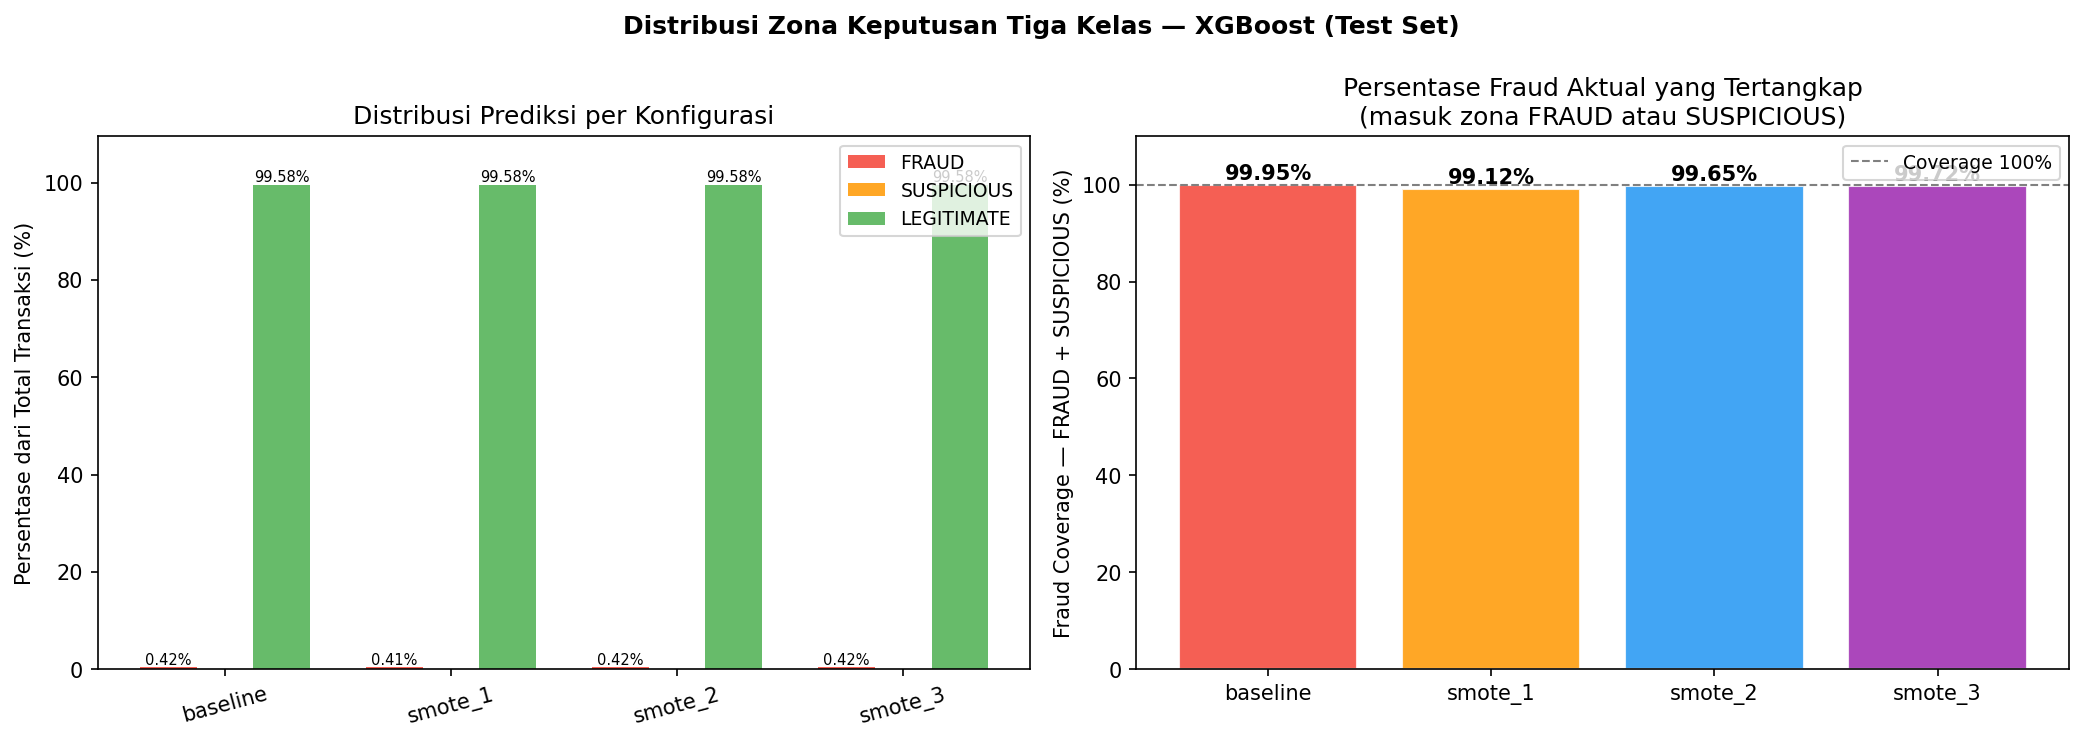


Analisis Threshold — baseline:


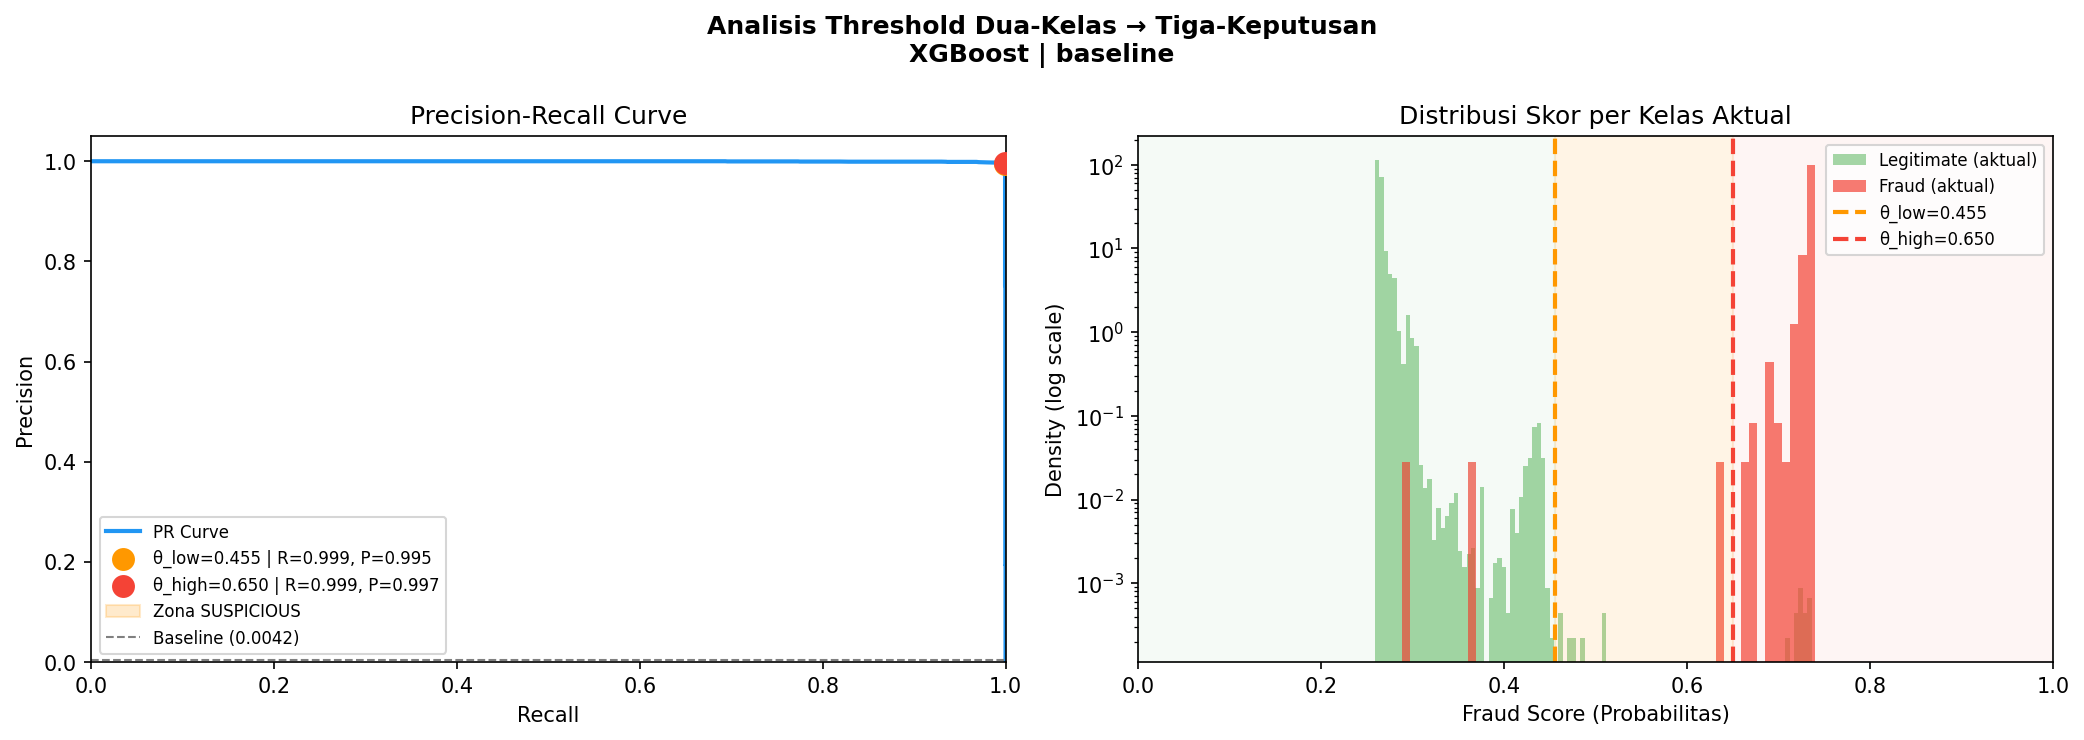


Analisis Threshold — smote_1:


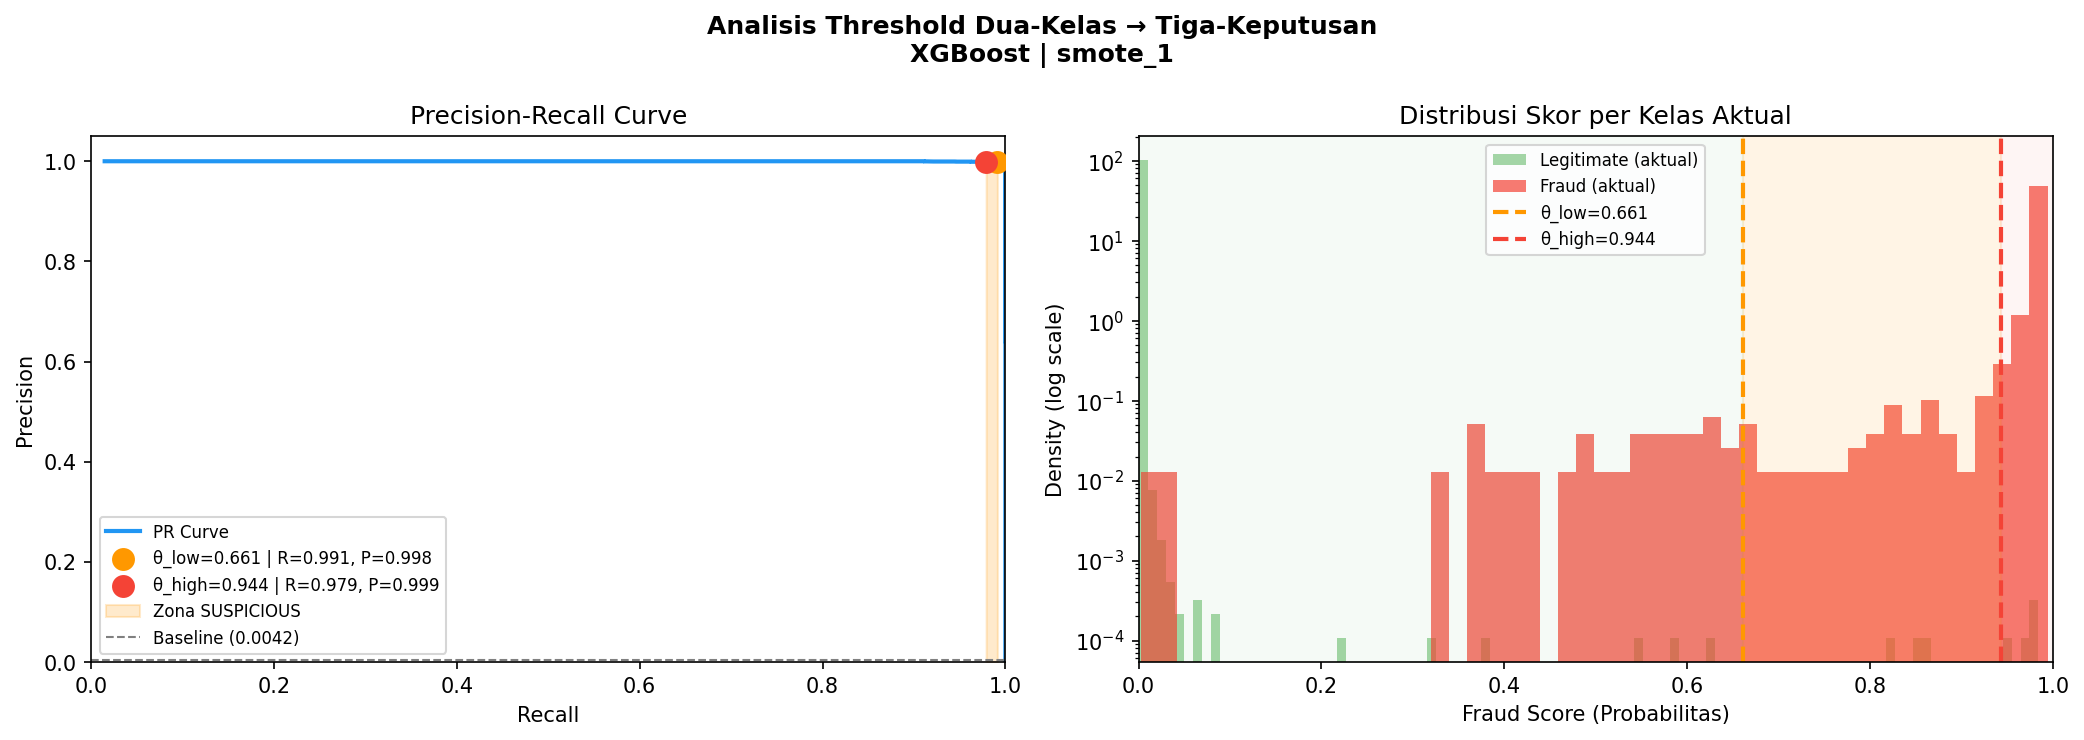


Analisis Threshold — smote_2:


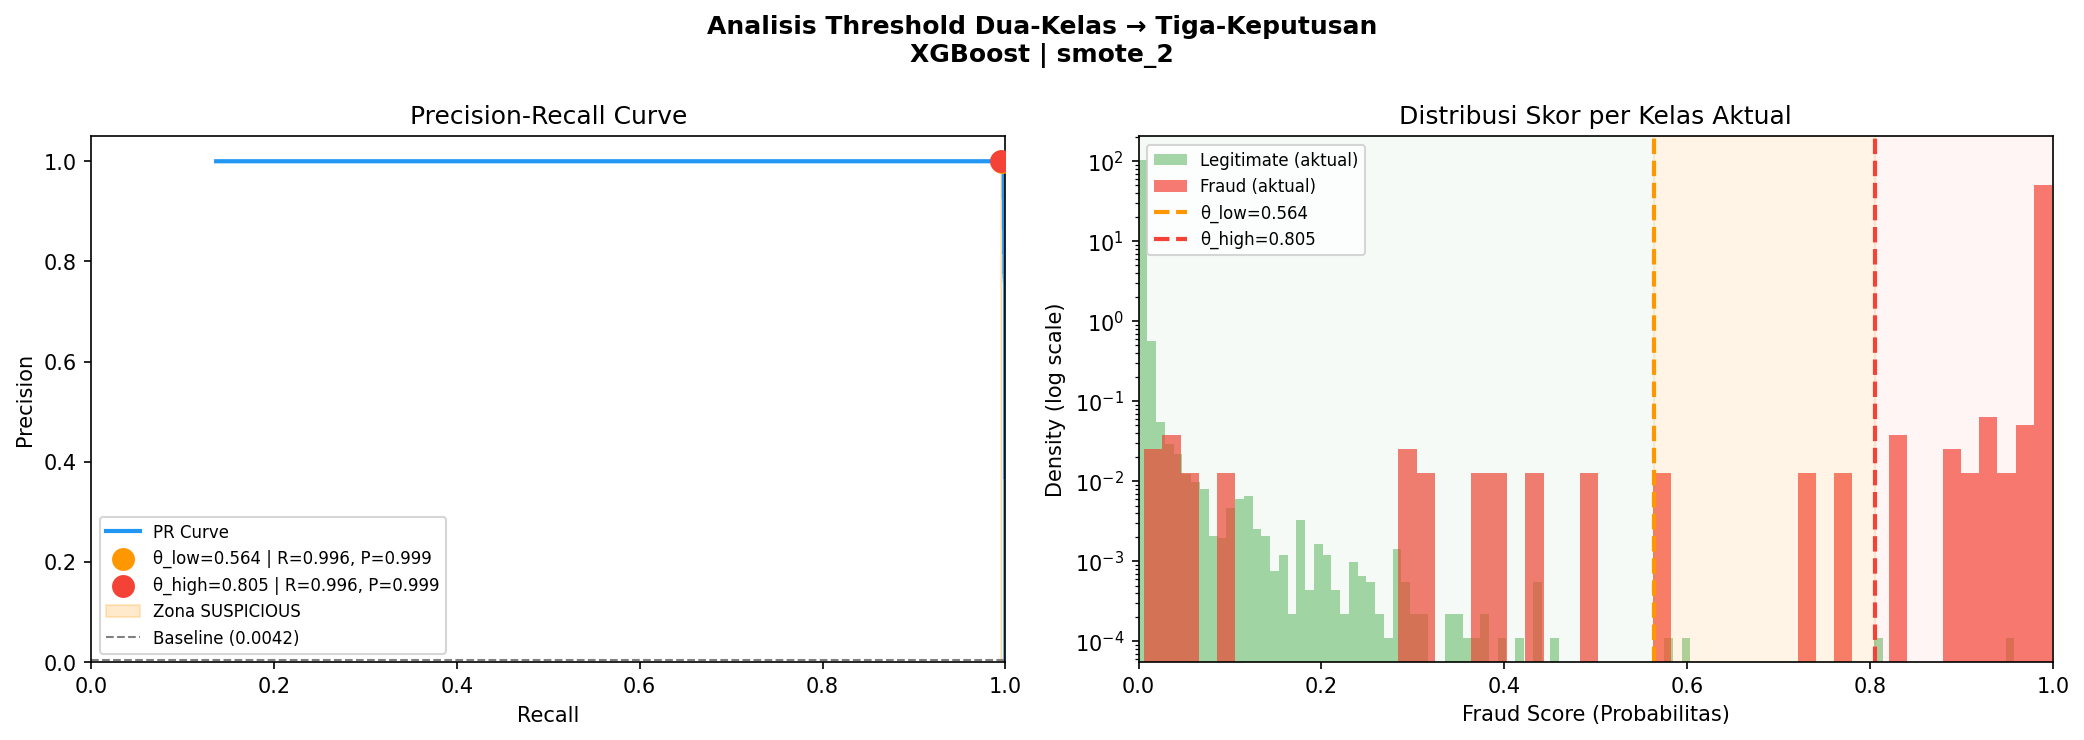


Analisis Threshold — smote_3:


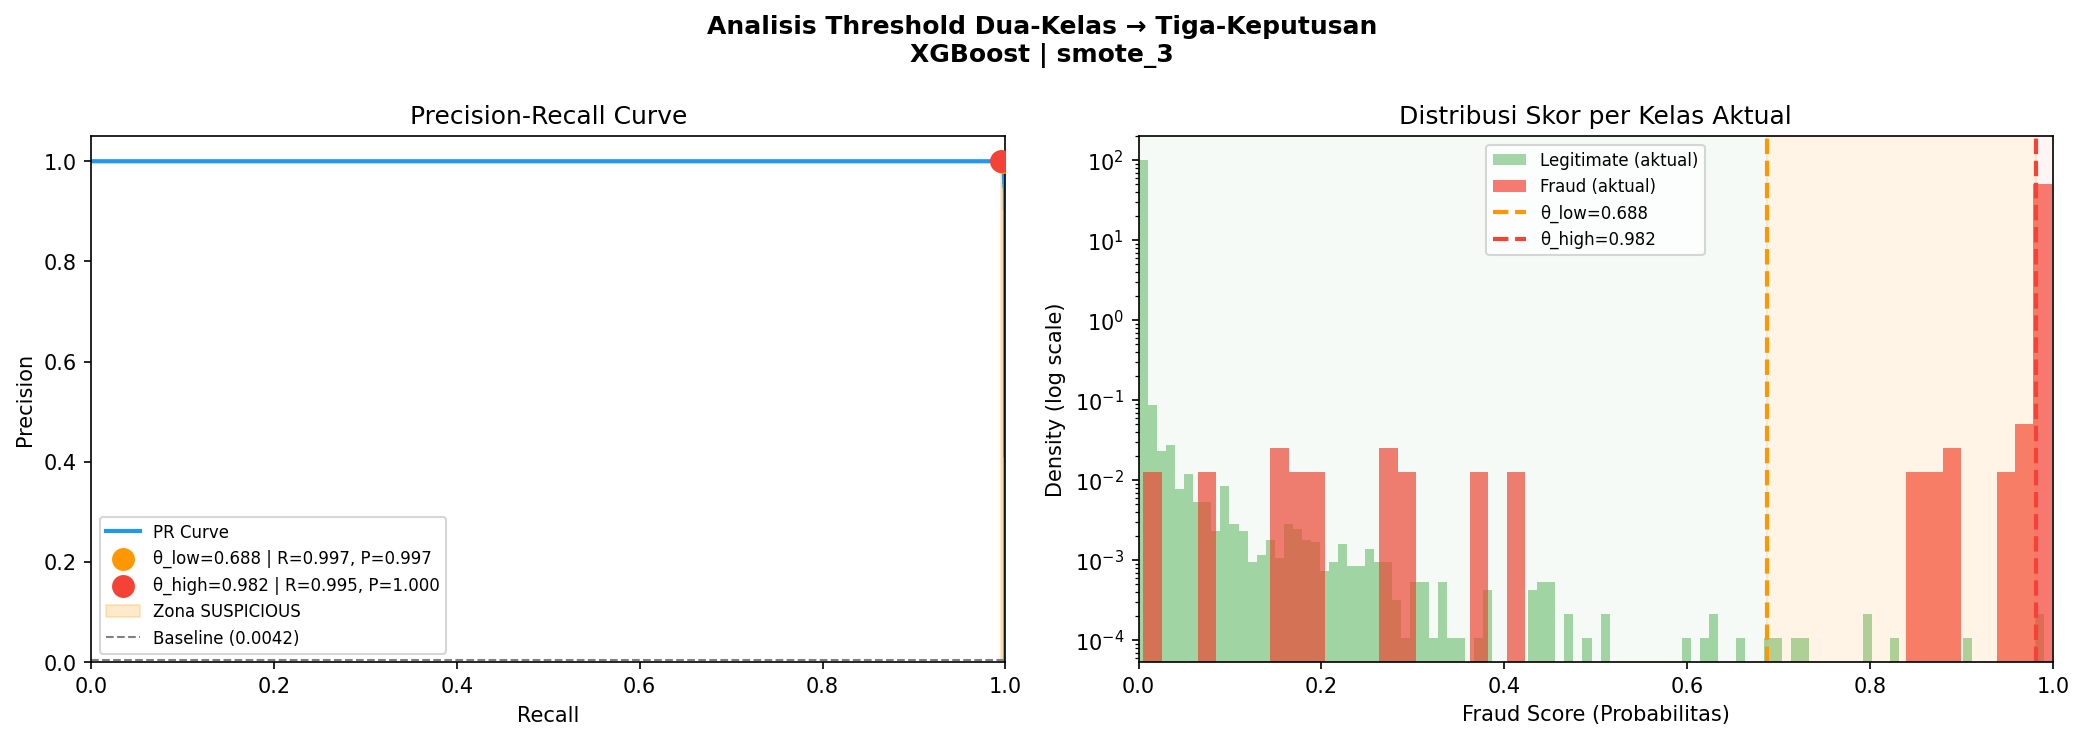

In [6]:
from IPython.display import Image, display
from config import SMOTE_CONFIGS

# Ringkasan gabungan
summary_path = FIGURES_DIR / "three_class_summary.png"
if summary_path.exists():
    print("Distribusi Zona Keputusan — Semua Konfigurasi:")
    display(Image(str(summary_path)))

# Per konfigurasi
for config_name in SMOTE_CONFIGS.keys():
    path = FIGURES_DIR / f"threshold_analysis_{config_name}.png"
    if path.exists():
        print(f"\nAnalisis Threshold — {config_name}:")
        display(Image(str(path)))

# Menampilkan Grafik


pr_roc_XGBoost.png:


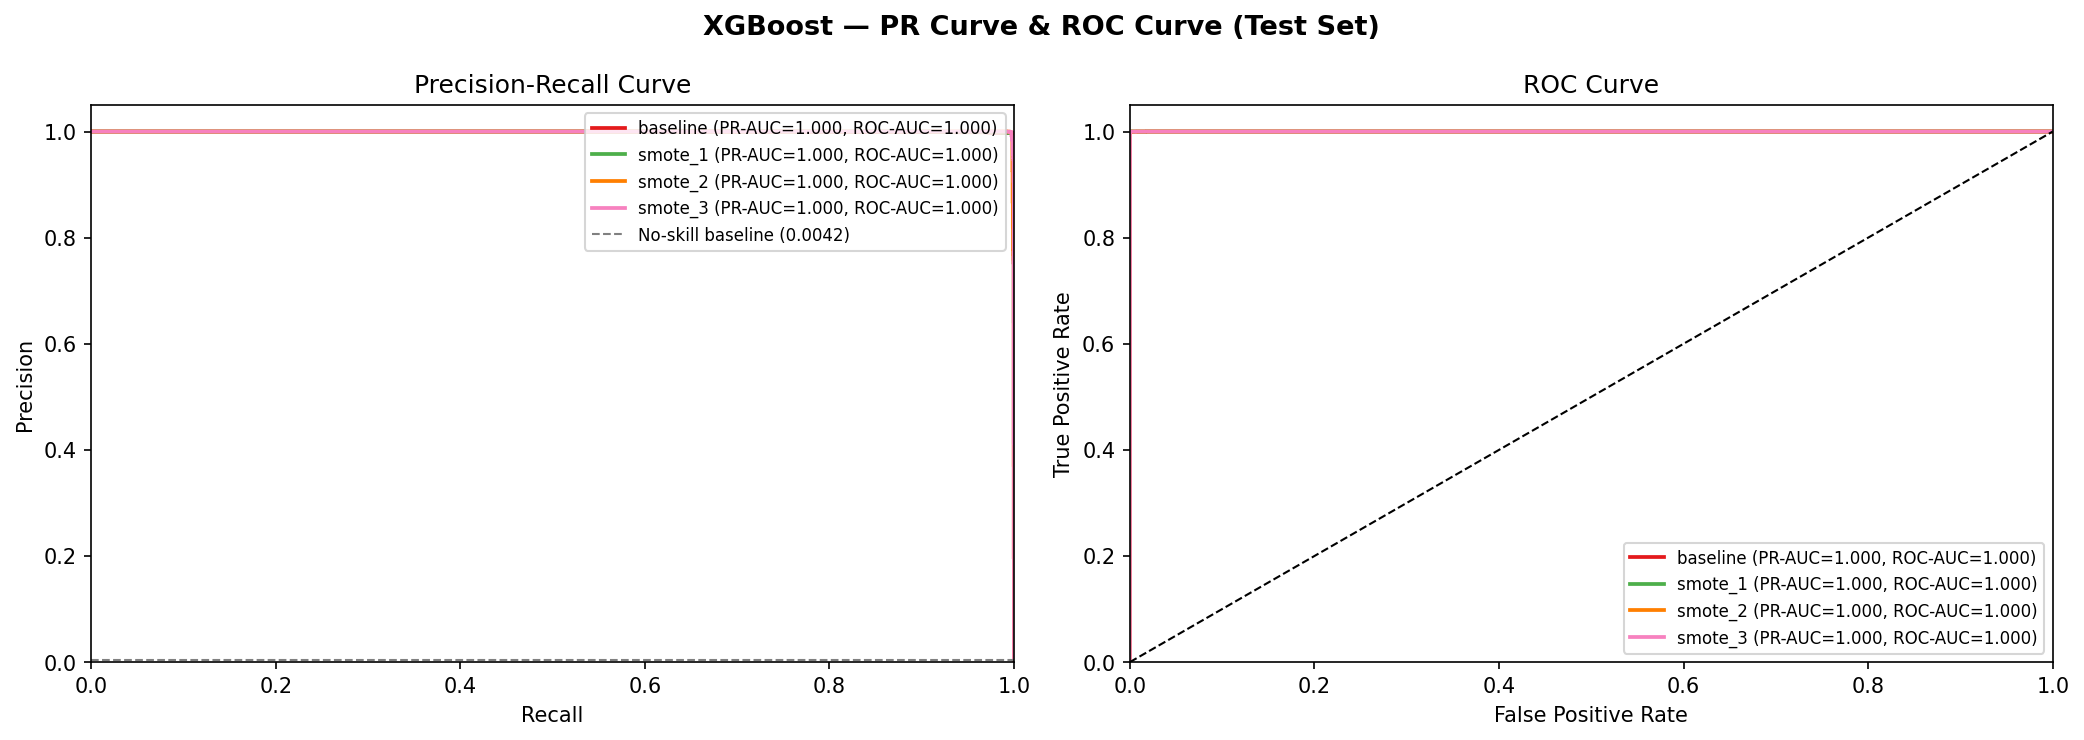


pr_roc_RandomForest.png:


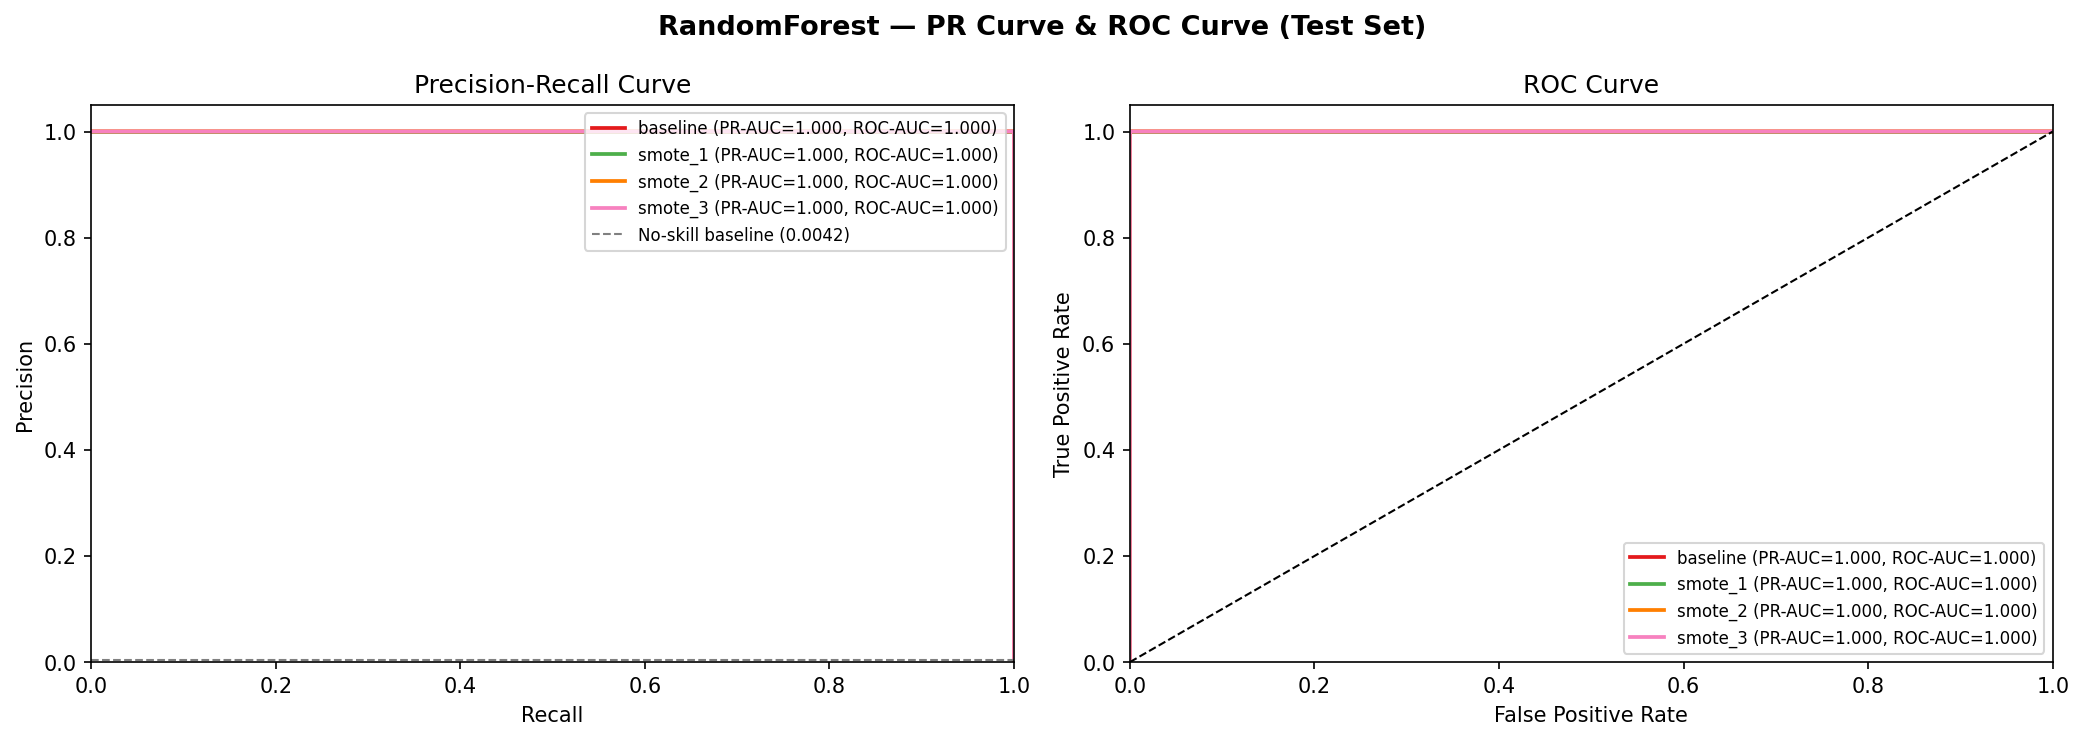


metrics_comparison_all.png:


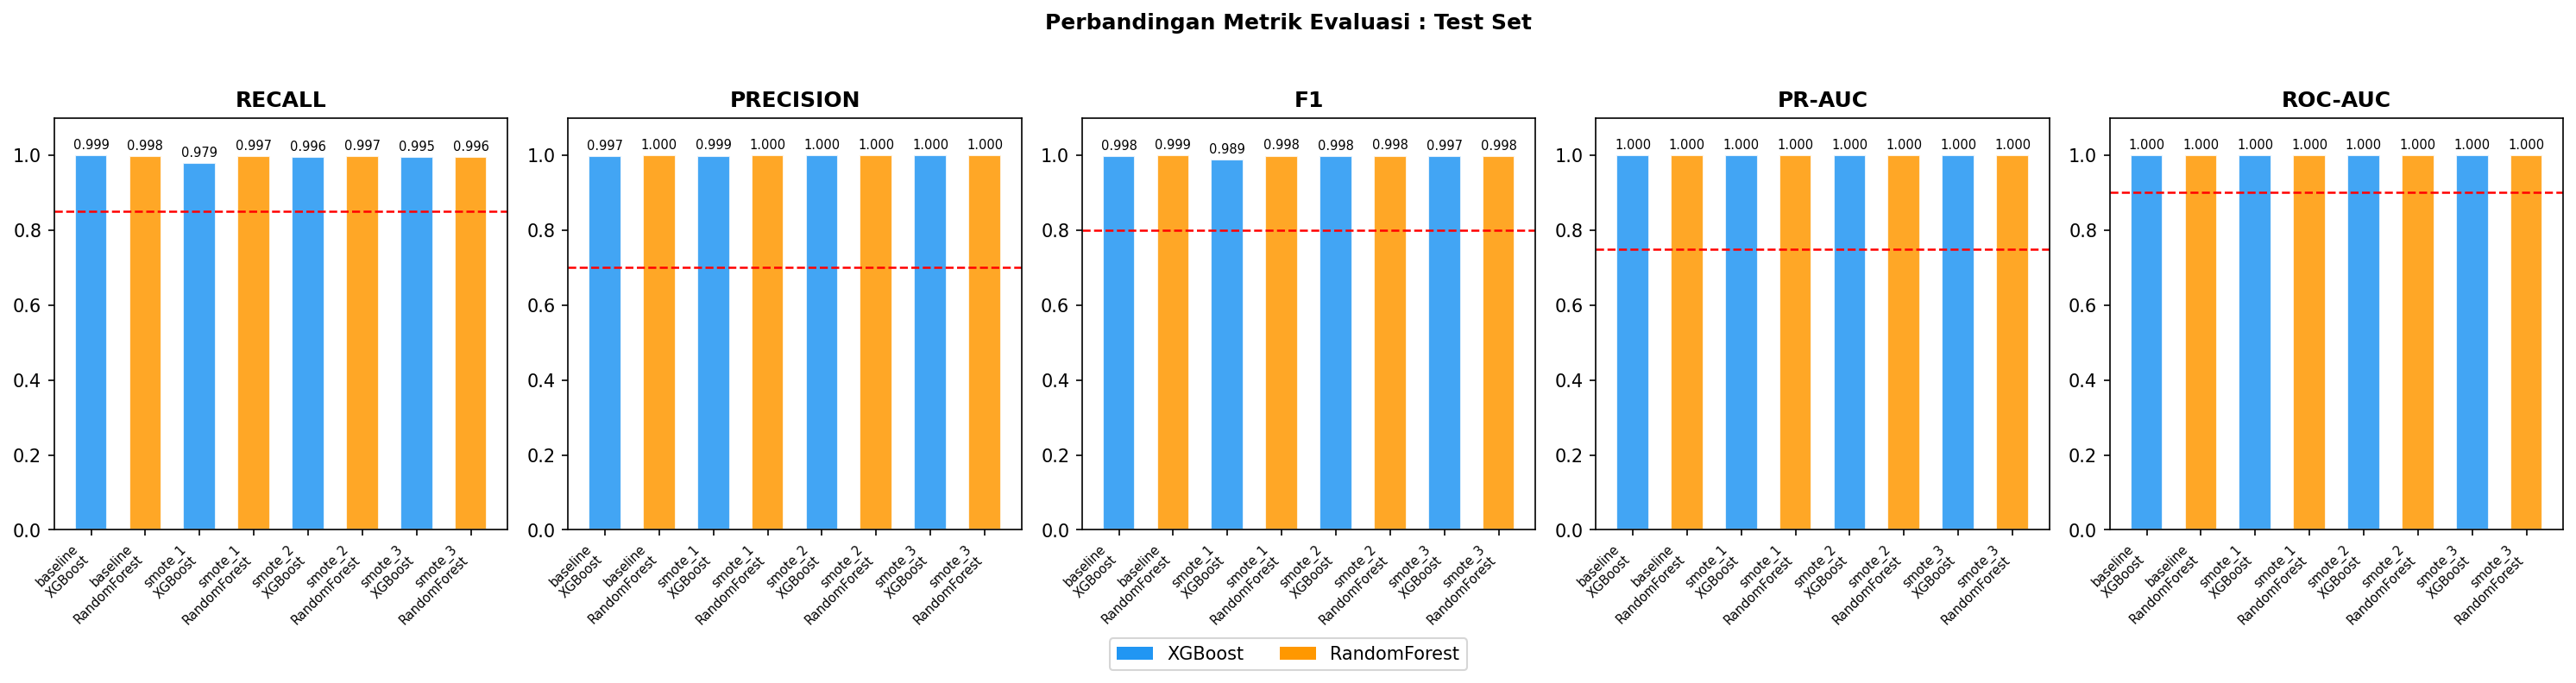

In [7]:
from IPython.display import Image, display

for fig_name in [
    "pr_roc_XGBoost.png",
    "pr_roc_RandomForest.png",
    "metrics_comparison_all.png"
]:
    path = FIGURES_DIR / fig_name
    if path.exists():
        print(f"\n{fig_name}:")
        display(Image(str(path)))